# Lecture 5 — Automatic Differentiation

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

Lecture 4 derived backpropagation by hand and the algebra was already unpleasant for a plain MLP.
It would have to be redone for every new architecture. This lecture replaces that labour with a
mechanism.

There are four ways to obtain a gradient. This notebook implements all four on the same function
and compares them, because the comparison is what explains why exactly one of them is what every
framework runs.

The running example, used by the lecture:

$$y = \ln(x_1) + x_1 x_2 - \sin(x_2) \quad \text{at} \quad x_1 = 2,\; x_2 = 5$$

Its true gradient is $\partial y/\partial x_1 = 1/x_1 + x_2$ and
$\partial y/\partial x_2 = x_1 - \cos x_2$, so every method below has something to be checked
against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """The running example. x is a length-2 array."""
    return np.log(x[0]) + x[0]*x[1] - np.sin(x[1])

def analytic_grad(x):
    return np.array([1.0/x[0] + x[1], x[0] - np.cos(x[1])])

x0 = np.array([2.0, 5.0])
print("f(2, 5)      =", round(float(f(x0)), 6))
print("true gradient =", np.round(analytic_grad(x0), 6))

f(2, 5)      = 11.652071
true gradient = [5.5      1.716338]


## 1. Numerical differentiation

Straight from the definition of a partial derivative, with $e_i$ the unit vector along axis $i$:

$$\frac{\partial f}{\partial \theta_i} \approx \frac{f(\theta + \epsilon e_i) - f(\theta)}{\epsilon}$$

The two-sided version is strictly better, and the Taylor expansion says why. Expanding
$f(\theta \pm \epsilon e_i)$ to second order, the $\epsilon^2$ terms are identical in both and
cancel on subtraction:

$$\frac{\partial f}{\partial \theta_i} = \frac{f(\theta + \epsilon e_i) - f(\theta - \epsilon e_i)}{2\epsilon} + O(\epsilon^2)$$

One-sided leaves error $O(\epsilon)$, two-sided leaves $O(\epsilon^2)$. That is a claim about
slopes on a log-log plot, so it can be measured.

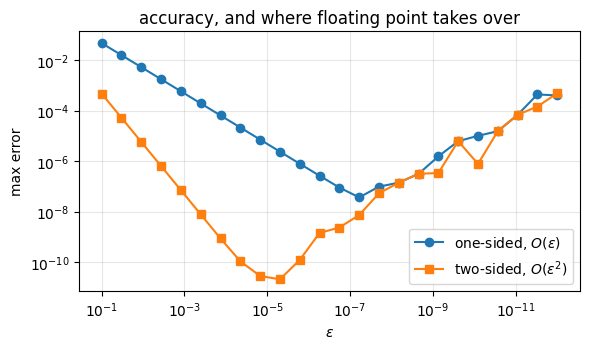

best one-sided error: 3.661e-08
best two-sided error: 2.073e-11


In [2]:
def grad_one_sided(f, x, eps):
    g = np.zeros_like(x)
    for i in range(x.size):
        e = np.zeros_like(x); e[i] = eps
        g[i] = (f(x + e) - f(x)) / eps
    return g

def grad_two_sided(f, x, eps):
    g = np.zeros_like(x)
    for i in range(x.size):
        e = np.zeros_like(x); e[i] = eps
        g[i] = (f(x + e) - f(x - e)) / (2 * eps)
    return g

truth = analytic_grad(x0)
eps_values = np.logspace(-1, -12, 24)
err1 = [np.abs(grad_one_sided(f, x0, e) - truth).max() for e in eps_values]
err2 = [np.abs(grad_two_sided(f, x0, e) - truth).max() for e in eps_values]

plt.figure(figsize=(6, 3.6))
plt.loglog(eps_values, err1, "o-", label=r"one-sided, $O(\epsilon)$")
plt.loglog(eps_values, err2, "s-", label=r"two-sided, $O(\epsilon^2)$")
plt.gca().invert_xaxis()
plt.xlabel(r"$\epsilon$"); plt.ylabel("max error"); plt.legend(); plt.grid(alpha=0.3)
plt.title("accuracy, and where floating point takes over")
plt.tight_layout(); plt.show()

print(f"best one-sided error: {min(err1):.3e}")
print(f"best two-sided error: {min(err2):.3e}")

Two things are visible. Going right to left the error falls, and the two-sided line falls twice
as steeply — that is the $O(\epsilon^2)$ against $O(\epsilon)$. Then both turn around and climb
again: once $\epsilon$ is small enough, $f(\theta+\epsilon)$ and $f(\theta-\epsilon)$ agree to
most of their significant digits, and the subtraction cancels away the information.

So there is a floor on the accuracy, and it is not especially low. Combined with the cost — each
parameter needs its own pair of evaluations, so $2n$ forward passes for one gradient — this is
not how anything is trained.

### Where it is genuinely used

It survives as the correctness check. Rather than probing every axis, take a random direction
$\delta$ from the unit ball; the same expansion gives

$$\delta^{\mathsf{T}} \nabla f(\theta) = \frac{f(\theta + \epsilon\delta) - f(\theta - \epsilon\delta)}{2\epsilon} + O(\epsilon^2)$$

Compute the left side from your autodiff implementation and the right from two function
evaluations. A handful of random directions covers things well. This is how the frameworks test
themselves, and it is the only reason the method still matters.

In [3]:
def directional_check(f, grad_fn, x, n_dirs=5, eps=1e-6, seed=0):
    """Check a gradient implementation along random directions."""
    rng = np.random.default_rng(seed)
    g = grad_fn(x)
    rows = []
    for _ in range(n_dirs):
        d = rng.normal(size=x.shape)
        d /= np.linalg.norm(d)                       # sample from the unit ball
        lhs = float(d @ g)                                    # from autodiff
        rhs = float((f(x + eps*d) - f(x - eps*d)) / (2*eps))  # from f alone
        rows.append((lhs, rhs, abs(lhs - rhs)))
    return rows

print(f"{'autodiff':>14}{'finite diff':>14}{'|difference|':>15}")
print("-" * 43)
for lhs, rhs, d in directional_check(f, analytic_grad, x0):
    print(f"{lhs:>14.8f}{rhs:>14.8f}{d:>15.2e}")

      autodiff   finite diff   |difference|
-------------------------------------------
    2.54851615    2.54851615       3.29e-10
    5.70510610    5.70510609       1.33e-09
   -3.59831810   -3.59831810       6.49e-10
    5.45873745    5.45873745       2.12e-10
   -4.17312042   -4.17312042       7.70e-10


## 2. Symbolic differentiation, and the waste it reveals

The other classical option is to write the gradient formula out by hand. Take
$f(\theta) = \prod_{i=1}^{n}\theta_i$. Differentiating gives

$$\frac{\partial f}{\partial \theta_k} = \prod_{j \neq k}\theta_j$$

which is clean — and evaluating it naively costs $n-2$ multiplications per parameter, so about
$n(n-2)$ for the whole gradient. Yet the same gradient is obtainable in roughly $n$
multiplications, because those $n$ products share almost all their factors.

In [4]:
def grad_product_naive(theta):
    """Evaluate each partial derivative independently. Counts multiplications."""
    n = len(theta)
    g, mults = np.zeros(n), 0
    for k in range(n):
        p = 1.0
        for j in range(n):
            if j != k:
                p *= theta[j]; mults += 1
        g[k] = p
    return g, mults

def grad_product_shared(theta):
    """Prefix and suffix products: every intermediate is reused."""
    n = len(theta)
    prefix, suffix, mults = np.ones(n), np.ones(n), 0
    for i in range(1, n):
        prefix[i] = prefix[i-1] * theta[i-1]; mults += 1
    for i in range(n-2, -1, -1):
        suffix[i] = suffix[i+1] * theta[i+1]; mults += 1
    g = prefix * suffix; mults += n
    return g, mults

theta = np.random.default_rng(0).uniform(0.5, 1.5, 200)
g1, m1 = grad_product_naive(theta)
g2, m2 = grad_product_shared(theta)

print("same gradient:", np.allclose(g1, g2))
print(f"naive  : {m1:>7,} multiplications")
print(f"shared : {m2:>7,} multiplications")
print(f"ratio  : {m1/m2:>7.1f}x  (n = {len(theta)})")

same gradient: True
naive  :  39,800 multiplications
shared :     598 multiplications
ratio  :    66.6x  (n = 200)


That gap is the entire point of the lecture. The symbolic formula is *correct* and its evaluation
is wasteful, because writing each partial derivative separately throws away work that could be
shared. Every method below exists to reuse intermediate results.

## 3. Computational graphs

A computational graph is a directed acyclic graph: each node is an intermediate value, each edge
an input-output relation. Evaluating means walking the nodes in topological order, so every input
is ready when its node is reached.

Building the running example explicitly makes the next two algorithms almost mechanical.

In [5]:
import math

# Each node: (name, op, [input node indices], local function)
# v1 = x1, v2 = x2, v3 = ln v1, v4 = v1*v2, v5 = sin v2, v6 = v3+v4, v7 = v6-v5
GRAPH = [
    ("v1", "input", [],      None),
    ("v2", "input", [],      None),
    ("v3", "ln",    [0],     lambda a:    math.log(a)),
    ("v4", "mul",   [0, 1],  lambda a, b: a * b),
    ("v5", "sin",   [1],     lambda a:    math.sin(a)),
    ("v6", "add",   [2, 3],  lambda a, b: a + b),
    ("v7", "sub",   [5, 4],  lambda a, b: a - b),
]

def evaluate_graph(inputs):
    """Forward pass in topological order. Returns the value of every node."""
    v = [None] * len(GRAPH)
    v[0], v[1] = inputs
    for i, (_, op, ins, fn) in enumerate(GRAPH):
        if op != "input":
            v[i] = fn(*[v[j] for j in ins])
    return v

vals = evaluate_graph((2.0, 5.0))
print(f"{'node':>6}{'op':>7}{'value':>12}")
print("-" * 25)
for (name, op, _, _), val in zip(GRAPH, vals):
    print(f"{name:>6}{op:>7}{val:>12.4f}")
print("\nf(2,5) from the graph =", round(vals[-1], 6))

  node     op       value
-------------------------
    v1  input      2.0000
    v2  input      5.0000
    v3     ln      0.6931
    v4    mul     10.0000
    v5    sin     -0.9589
    v6    add     10.6931
    v7    sub     11.6521

f(2,5) from the graph = 11.652071


## 4. Forward mode

Define $\dot{v}_i = \partial v_i / \partial x_1$ and propagate it alongside the values, in the
same topological order. The seeds are trivial: $\dot{v}_1 = 1$ because $v_1$ *is* $x_1$, and
$\dot{v}_2 = 0$ because $v_2$ has nothing to do with $x_1$. Every other node applies the local
rule to the dots of its inputs.

In [6]:
# Local derivative rules: given input values, return d(output)/d(each input).
LOCAL = {
    "ln":  lambda a:    (1.0 / a,),
    "mul": lambda a, b: (b, a),
    "sin": lambda a:    (math.cos(a),),
    "add": lambda a, b: (1.0, 1.0),
    "sub": lambda a, b: (1.0, -1.0),
}

def forward_mode(inputs, wrt):
    """Derivative of every node with respect to input `wrt` (0 or 1)."""
    v = evaluate_graph(inputs)
    dot = [0.0] * len(GRAPH)
    dot[wrt] = 1.0                                    # seed at the input
    for i, (_, op, ins, _) in enumerate(GRAPH):
        if op == "input":
            continue
        partials = LOCAL[op](*[v[j] for j in ins])    # local derivatives
        dot[i] = sum(p * dot[j] for p, j in zip(partials, ins))
    return v, dot

vals, dots = forward_mode((2.0, 5.0), wrt=0)
print(f"{'node':>6}{'value':>12}{'v_dot':>12}")
print("-" * 30)
for (name, _, _, _), val, d in zip(GRAPH, vals, dots):
    print(f"{name:>6}{val:>12.4f}{d:>12.4f}")
print(f"\ndy/dx1 from forward mode = {dots[-1]:.4f}")
print(f"analytic                 = {analytic_grad(x0)[0]:.4f}")

  node       value       v_dot
------------------------------
    v1      2.0000      1.0000
    v2      5.0000      0.0000
    v3      0.6931      0.5000
    v4     10.0000      5.0000
    v5     -0.9589      0.0000
    v6     10.6931      5.5000
    v7     11.6521      5.5000

dy/dx1 from forward mode = 5.5000
analytic                 = 5.5000


Correct — but notice what one pass bought: the derivative with respect to **one** input.

For a function $\mathbb{R}^n \to \mathbb{R}^k$, forward mode is excellent when $n$ is small and
$k$ is large: one pass gives the derivative of every output with respect to one input. Deep
learning is the exact opposite — millions of parameters, one scalar loss. Forward mode would need
$n$ passes.

In [7]:
print("forward mode, one pass per input:")
for i, name in enumerate(["x1", "x2"]):
    _, d = forward_mode((2.0, 5.0), wrt=i)
    print(f"  pass {i+1}  ->  dy/d{name} = {d[-1]:.4f}")
print("\nFor a network with a million parameters, that is a million passes.")

forward mode, one pass per input:
  pass 1  ->  dy/dx1 = 5.5000
  pass 2  ->  dy/dx2 = 1.7163

For a network with a million parameters, that is a million passes.


## 5. Reverse mode

Flip the definition. The **adjoint** of a node is the derivative of the scalar output with
respect to that node,

$$\overline{v_i} = \frac{\partial y}{\partial v_i}$$

and now the trivial seed sits at the *end*: $\overline{v_7} = \partial y/\partial v_7 = 1$. Walk
the graph backwards, and each node's adjoint follows from the adjoint of whatever consumed it.

When a node feeds several consumers, the contributions **add** — that is the multivariate chain
rule, and each term is a *partial adjoint* belonging to an edge rather than a node:

$$\overline{v_i} = \sum_{j \in \mathrm{next}(i)} \overline{v_j}\,\frac{\partial v_j}{\partial v_i}$$

In [8]:
def reverse_mode(inputs):
    """All partial derivatives in a single backward pass."""
    v = evaluate_graph(inputs)
    partial_adjoints = {i: [] for i in range(len(GRAPH))}   # edge contributions
    partial_adjoints[len(GRAPH) - 1] = [1.0]                # seed at the output
    adjoint = [0.0] * len(GRAPH)

    for i in reversed(range(len(GRAPH))):                   # reverse topological order
        adjoint[i] = sum(partial_adjoints[i])               # node adjoint = sum of edges
        name, op, ins, _ = GRAPH[i]
        if op == "input":
            continue
        partials = LOCAL[op](*[v[j] for j in ins])
        for p, j in zip(partials, ins):
            partial_adjoints[j].append(adjoint[i] * p)      # v_{j->i}
    return v, adjoint

vals, adj = reverse_mode((2.0, 5.0))
print(f"{'node':>6}{'value':>12}{'adjoint':>12}{'contributions':>16}")
print("-" * 46)
for i in reversed(range(len(GRAPH))):
    n_in = len([1 for (_, op, ins, _) in GRAPH if i in ins])
    print(f"{GRAPH[i][0]:>6}{vals[i]:>12.4f}{adj[i]:>12.4f}{n_in:>16}")

print(f"\nreverse mode gradient = [{adj[0]:.4f}, {adj[1]:.4f}]")
print(f"analytic gradient     = {np.round(analytic_grad(x0), 4)}")
assert np.allclose([adj[0], adj[1]], analytic_grad(x0))
print("\nboth partial derivatives, one backward pass")

  node       value     adjoint   contributions
----------------------------------------------
    v7     11.6521      1.0000               0
    v6     10.6931      1.0000               1
    v5     -0.9589     -1.0000               1
    v4     10.0000      1.0000               1
    v3      0.6931      1.0000               1
    v2      5.0000      1.7163               2
    v1      2.0000      5.5000               2

reverse mode gradient = [5.5000, 1.7163]
analytic gradient     = [5.5    1.7163]

both partial derivatives, one backward pass


The last column is the number of consumers. $v_1$ and $v_2$ each feed two nodes, which is exactly
where the summation rule was needed — the contributions from both pathways add.

That asymmetry between forward and reverse is the whole reason deep learning is trainable:

| | cost of a full gradient |
|---|---|
| numerical | $2n$ forward passes |
| forward mode | $n$ passes |
| reverse mode | **1 backward pass** |

## 6. Storing nodes instead of numbers

One design decision separates modern frameworks from their predecessors. When the algorithm
computes a partial adjoint, does it store a **number** or a **node**?

Backpropagation stores numbers: it walks the original graph backwards computing concrete arrays,
creating nothing new. That is what `reverse_mode` above does, and what cuda-convnet and Caffe did.

Reverse-mode AD by *extending the graph* stores nodes: each partial adjoint becomes a new node
appended to the same graph, so differentiating a graph returns another graph. Theano pioneered
this; TensorFlow and PyTorch made it standard.

The consequence worth the extra structure: the gradient is itself differentiable. Below, the same
machinery runs symbolically — every adjoint comes back as an expression, valid for *any* input,
rather than a number valid only at $(2, 5)$.

In [9]:
class Expr:
    """A symbolic expression node. Operators build more nodes instead of numbers."""
    def __init__(self, s): self.s = s
    def __add__(self, o): return Expr(f"({self.s} + {o.s})")
    def __sub__(self, o): return Expr(f"({self.s} - {o.s})")
    def __mul__(self, o):
        if self.s == "1": return o                      # fold identity nodes
        if o.s == "1":    return self
        return Expr(f"({self.s} * {o.s})")
    def __repr__(self): return self.s

SYM = {
    "ln":  lambda a:    (Expr(f"(1/{a})"),),
    "mul": lambda a, b: (b, a),
    "sin": lambda a:    (Expr(f"cos({a})"),),
    "add": lambda a, b: (Expr("1"), Expr("1")),
    "sub": lambda a, b: (Expr("1"), Expr("-1")),
}

def reverse_mode_symbolic():
    """Identical algorithm - only the arithmetic changed from floats to nodes."""
    sym = [Expr(g[0]) for g in GRAPH]                    # v1 ... v7 as symbols
    parts = {i: [] for i in range(len(GRAPH))}
    parts[len(GRAPH) - 1] = [Expr("1")]
    adj = [None] * len(GRAPH)
    for i in reversed(range(len(GRAPH))):
        acc = parts[i][0]
        for extra in parts[i][1:]:
            acc = acc + extra
        adj[i] = acc
        _, op, ins, _ = GRAPH[i]
        if op == "input":
            continue
        for p, j in zip(SYM[op](*[sym[t] for t in ins]), ins):
            parts[j].append(adj[i] * p)
    return adj

adj_sym = reverse_mode_symbolic()
print("adjoint of v1  (i.e. dy/dx1) =", adj_sym[0])
print("adjoint of v2  (i.e. dy/dx2) =", adj_sym[1])

adjoint of v1  (i.e. dy/dx1) = (v2 + (1/v1))
adjoint of v2  (i.e. dy/dx2) = ((-1 * cos(v2)) + v1)


Those are expressions, not numbers. `(1/v1)` and `v2` recover $1/x_1 + x_2$; `cos(v2)` with the
$-1$ recovers $x_1 - \cos x_2$. The same graph evaluates at any input, and — the real prize —
it can be differentiated again, which is where gradient-of-gradient comes from.

## 7. Lifting it to tensors

Everything so far was scalar. Generalise by defining the adjoint of a matrix elementwise: the
adjoint of $Z$ is the matrix whose $(i,j)$ entry is $\partial y/\partial Z_{ij}$. Then derive in
scalars and read the result back as matrices. For $Z = XW$ we have
$Z_{ij} = \sum_k X_{ik}W_{kj}$, and $X_{ik}$ feeds every $Z_{ij}$, so all those pathways sum:

$$\overline{X_{ik}} = \sum_j \overline{Z_{ij}}\, W_{kj}
\qquad\Longrightarrow\qquad \overline{X} = \overline{Z}\, W^{\mathsf{T}}$$

That is the linear-layer rule from lecture 4 — the same $W^{\mathsf{T}}$ that appeared there by
shape matching, now actually derived.

In [10]:
rng = np.random.default_rng(0)
X = rng.normal(size=(5, 4))
W = rng.normal(size=(4, 3))
Zbar = rng.normal(size=(5, 3))       # pretend adjoint arriving from above

# The scalar definition, applied entry by entry.
Xbar_loop = np.zeros_like(X)
for i in range(X.shape[0]):
    for kk in range(X.shape[1]):
        Xbar_loop[i, kk] = sum(Zbar[i, j] * W[kk, j] for j in range(W.shape[1]))

Xbar_matrix = Zbar @ W.T             # the rule we want to justify

print("elementwise definition == Zbar @ W.T :", np.allclose(Xbar_loop, Xbar_matrix))
print("max difference                       :", np.abs(Xbar_loop - Xbar_matrix).max())
print("\nshapes:", Zbar.shape, "@", W.T.shape, "->", Xbar_matrix.shape, "== X", X.shape)

elementwise definition == Zbar @ W.T : True
max difference                       : 4.440892098500626e-16

shapes: (5, 3) @ (3, 4) -> (5, 4) == X (5, 4)


## Summary

- **Numerical**: $2n$ forward passes, and a hard accuracy floor from cancellation. Survives as the gradient checker, using a random direction rather than every axis.
- **Symbolic**: correct and wasteful — $n(n-2)$ multiplications where $n$ would do, because separate formulas cannot share intermediates.
- **Forward mode**: propagates $\dot{v}_i$ from the inputs. One pass per *input*. Right for few-inputs-many-outputs; exactly backwards for deep learning.
- **Reverse mode**: propagates the adjoint $\overline{v_i}$ from the output. The whole gradient in one backward pass.
- Storing adjoints as **graph nodes** rather than numbers makes the gradient itself differentiable, and gives the framework something to optimize.

Next: build the data structures that make this a framework — a tensor that remembers how it was
computed.